In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from lab_utils_multi import load_house_data
from lab_utils_common import dlc
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

plt.style.use('./deeplearning.mplstyle')


In [3]:
X_train,Y_train = load_house_data()

In [5]:
Y_train

array([300.  , 509.8 , 394.  , 540.  , 415.  , 230.  , 560.  , 294.  ,
       718.2 , 200.  , 302.  , 468.  , 374.2 , 388.  , 282.  , 311.8 ,
       401.  , 449.8 , 301.  , 502.  , 340.  , 400.28, 572.  , 264.  ,
       304.  , 298.  , 219.8 , 490.7 , 216.96, 368.2 , 280.  , 526.87,
       237.  , 562.43, 369.8 , 460.  , 374.  , 390.  , 158.  , 426.  ,
       390.  , 277.77, 216.96, 425.8 , 504.  , 329.  , 464.  , 220.  ,
       358.  , 478.  , 334.  , 426.98, 290.  , 463.  , 390.8 , 354.  ,
       350.  , 460.  , 237.  , 288.3 , 282.  , 249.  , 304.  , 332.  ,
       351.8 , 310.  , 216.96, 666.34, 330.  , 480.  , 330.3 , 348.  ,
       304.  , 384.  , 316.  , 430.4 , 450.  , 284.  , 275.  , 414.  ,
       258.  , 378.  , 350.  , 412.  , 373.  , 225.  , 390.  , 267.4 ,
       464.  , 174.  , 340.  , 430.  , 440.  , 216.  , 329.  , 388.  ,
       390.  , 356.  , 257.8 ])

In [6]:
X_features = ['size(sqft)' , 'bedrooms' , 'floor' , 'age']

In [7]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

In [10]:
print("peak   to peak range by column in Raw   X: " , np.ptp(X_train, axis=0) )
print("peak   to peak range by column in Normalized   X: " , np.ptp(X_norm, axis=0) )

peak   to peak range by column in Raw   X:  [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
peak   to peak range by column in Normalized   X:  [5.85 6.14 2.06 3.69]


In [12]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm,Y_train)
print(sgdr)
print(f"Number of iterations completed: {sgdr.n_iter_} , number of weight updates : {sgdr.t_}")

SGDRegressor()
Number of iterations completed: 142 , number of weight updates : 14059.0


In [13]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_

print(f"Model parameters:        w: {w_norm} , b: {b_norm}")
print(f"Model parameters from previous lab :   w: [110.56 -21.27 -32.71 -37.97], b: 363.16]")

Model parameters:        w: [110.3  -21.17 -32.59 -38.01] , b: [363.18]
Model parameters from previous lab :   w: [110.56 -21.27 -32.71 -37.97], b: 363.16]


In [16]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm,w_norm) +b_norm

print(f"Prediction Using np.dot() ans sgdr.predict match :  {(y_pred == y_pred_sgd).all()}")
print(f"Prediction Using np.dot()  :  {y_pred}")
print(f"Prediction Using sgdr.predict  :  { y_pred_sgd}")

Prediction Using np.dot() ans sgdr.predict match :  True
Prediction Using np.dot()  :  [295.22 485.88 389.53 492.04 420.18 222.93 523.15 267.77 684.34 181.92
 318.19 479.39 409.94 393.51 286.97 323.36 406.02 436.44 270.05 500.43
 328.66 388.24 551.04 241.55 295.64 282.56 217.39 491.   228.8  341.44
 291.48 490.03 238.43 598.23 383.73 452.78 401.18 406.02 172.37 423.57
 434.36 277.03 228.8  448.52 488.96 331.99 465.67 221.86 386.76 456.56
 370.39 468.68 310.39 426.52 391.77 347.74 339.13 471.43 243.51 298.22
 272.98 249.87 298.06 334.88 376.01 288.93 228.8  620.74 352.7  510.92
 364.15 363.28 298.06 407.26 288.67 386.06 488.15 261.07 258.95 427.54
 238.29 355.78 339.83 390.3  381.77 220.34 434.36 243.51 465.67 185.94
 341.44 410.05 445.58 232.13 331.99 409.04 406.02 351.52 274.24]
Prediction Using sgdr.predict  :  [295.22 485.88 389.53 492.04 420.18 222.93 523.15 267.77 684.34 181.92
 318.19 479.39 409.94 393.51 286.97 323.36 406.02 436.44 270.05 500.43
 328.66 388.24 551.04 241.55 295.

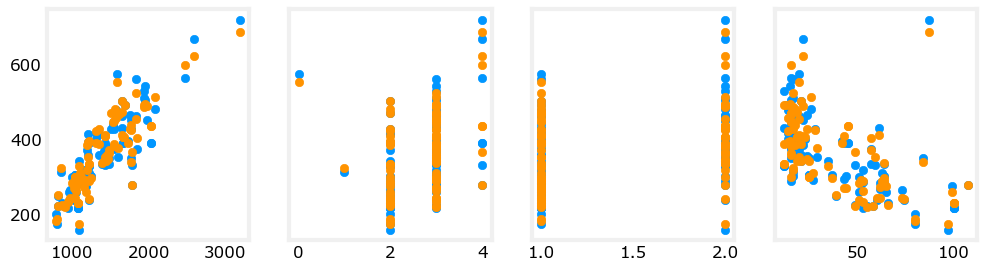

In [17]:
fig, ax = plt.subplots(1,4, figsize= (12,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], Y_train)
    ax[i].scatter(X_train[:,i],y_pred)